In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as mcolors
import networkx as nx


In [271]:
colors = ['white', '#f5821f']

WhiteToDDOrange = mcolors.LinearSegmentedColormap.from_list(
    name='WhiteToDDOrange',
    colors=colors,
    N=256 # N is the number of discrete steps/colors in the map (higher is smoother)
)

colors2 = ['#e11383', 'white']

WhiteToDDPink = mcolors.LinearSegmentedColormap.from_list(
    name='WhiteToDDPink',
    colors=colors2,
    N=256 # N is the number of discrete steps/colors in the map (higher is smoother)
)

In [210]:
df = pd.read_csv('./Japan.csv')
df.drop(columns = ['X', 'Unnamed: 0'], inplace = True)
df.head()

,Prefecture,Capital_Lat,Capital_Long,PopThousands_2015,year,week,HFMD_cases,time_clean
0,Hokkaido,43.066667,141.35,5382,2000,1,2,2000.019231
1,Hokkaido,43.066667,141.35,5382,2000,2,3,2000.038462
2,Hokkaido,43.066667,141.35,5382,2000,3,4,2000.057692
3,Hokkaido,43.066667,141.35,5382,2000,4,1,2000.076923
4,Hokkaido,43.066667,141.35,5382,2000,5,5,2000.096154


In [179]:
print('min year: ', df['year'].min())
print('max year: ', df['year'].max())
print('num prefect:', len(df['Prefecture'].unique()))


min year:  2000
max year:  2015
num prefect: 47


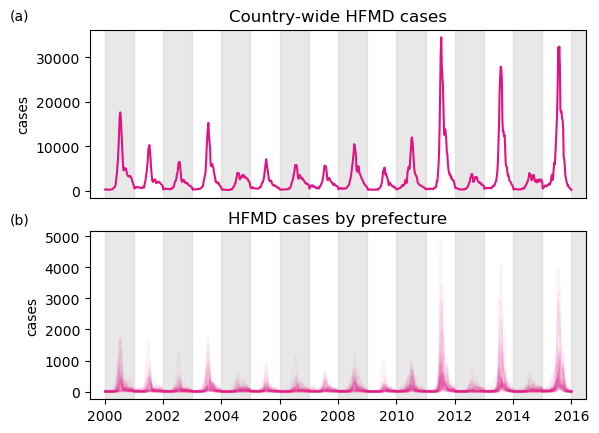

In [180]:
case_sum_df = df.groupby(['time_clean'])['HFMD_cases'].sum().reset_index()
case_sum_df.head()

fig = plt.figure()
ax = fig.add_subplot(211)
ax.plot(case_sum_df['time_clean'], case_sum_df['HFMD_cases'],
        color = '#e11383')

ax2 = fig.add_subplot(212)

for prefect in df['Prefecture'].unique():
    case_sum_prefect_df = df[df['Prefecture'] == prefect].groupby(['time_clean'])['HFMD_cases'].sum().reset_index()
    ax2.plot(case_sum_prefect_df['time_clean'], case_sum_prefect_df['HFMD_cases'],
        color = '#e11383', 
        alpha = .05)

year_list = [[i, i + 1] for i in range(2000, 2017, 2)]


for year in year_list:
    ax.axvspan(year[0], year[1], color = 'lightgrey', alpha = .5)
    ax2.axvspan(year[0], year[1], color = 'lightgrey', alpha = .5)

ax.set(xlim = [1999.5, 2016.5], 
       xticks = [], xticklabels = [], 
       ylabel = 'cases', 
       title = 'Country-wide HFMD cases')
ax2.set(xlim = [1999.5, 2016.5], 
        ylabel = 'cases',
        title = 'HFMD cases by prefecture')

fig.text(0, .9, '(a)')
fig.text(0, .475, '(b)')

fig.savefig('./figures/assignment4/hfmd_yearly_trends.png', dpi = 500)

In [242]:
df_pref_by_week = df.groupby(['Prefecture', 'week', 'Capital_Lat', 'Capital_Long'])['HFMD_cases'].mean().reset_index().sort_values(by='Capital_Lat')

prefects = df_pref_by_week['Prefecture'].unique().tolist()
prefects.reverse()

df_pref_by_week_pivot = pd.pivot_table(data = df_pref_by_week, index = 'Prefecture', columns = 'week', values = 'HFMD_cases', sort = True)
df_pref_by_week_pivot = df_pref_by_week_pivot.div(df_pref_by_week_pivot.max(axis = 1), axis = 0)
df_pref_by_week_pivot = df_pref_by_week_pivot.reindex(prefects)

In [243]:
df_pref_by_week

,Prefecture,week,Capital_Lat,Capital_Long,HFMD_cases
1670,Okinawa,28,26.500000,127.933333,38.5000
1667,Okinawa,25,26.500000,127.933333,49.6875
1666,Okinawa,24,26.500000,127.933333,52.8750
1665,Okinawa,23,26.500000,127.933333,58.2500
1664,Okinawa,22,26.500000,127.933333,63.8125
...,...,...,...,...,...
607,Hokkaido,25,43.066667,141.350000,61.1875
608,Hokkaido,26,43.066667,141.350000,95.5000
609,Hokkaido,27,43.066667,141.350000,139.8125
584,Hokkaido,2,43.066667,141.350000,14.8125


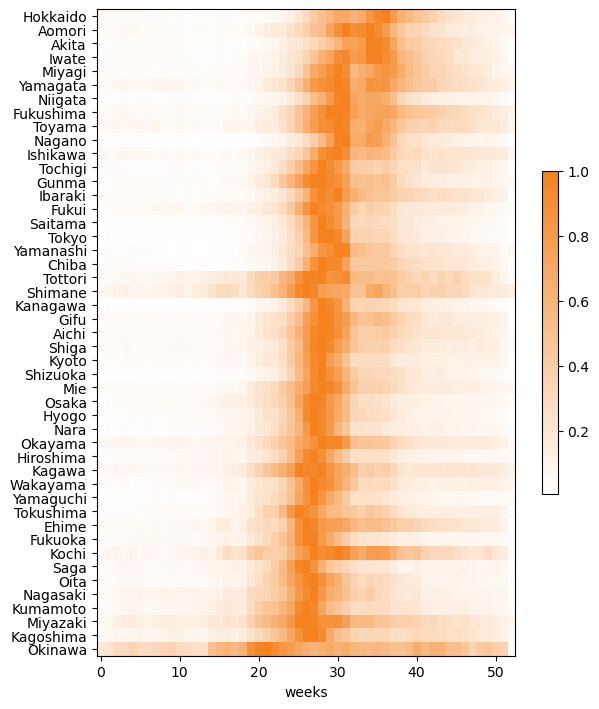

In [244]:
fig = plt.figure(figsize = [6.4, 4.8*1.5], tight_layout = True)
ax = fig.add_subplot(111)

heatmap = ax.imshow(df_pref_by_week_pivot, 
          cmap = WhiteToDDOrange)

fig.colorbar(heatmap, ax = ax, 
             shrink = .5)
prefects = df_pref_by_week_pivot.index.tolist()
ax.set(yticks = range(len(prefects)), yticklabels = prefects, 
       xlabel = 'weeks', 
       aspect = 'auto')

fig.savefig('./figures/assignment4/prefect_by_week.png', dpi = 500)

In [ ]:
df_max = df_pref_by_week.loc[df_pref_by_week.groupby('Prefecture')['HFMD_cases'].idxmax()]

,Prefecture,week,Capital_Lat,Capital_Long,HFMD_cases
28,Aichi,29,35.181456,136.906386,607.2500
87,Akita,35,39.720028,140.102583,119.7500
140,Aomori,35,40.816667,140.750000,159.6875
187,Chiba,29,35.600000,140.100000,477.7500
238,Ehime,27,33.833333,132.766667,150.4375
292,Fukui,28,36.066667,136.216667,125.5625
345,Fukuoka,28,33.583333,130.400000,790.8750
400,Fukushima,30,37.766667,140.466667,147.6875
452,Gifu,29,35.416667,136.766667,145.6875
504,Gunma,28,36.383333,139.066667,203.3750


In [312]:
df_max.sort_values(by = 'HFMD_cases', ascending = False).reset_index()
df_max = df_max.head(10)

df_pref_by_week = df_pref_by_week[df_pref_by_week['Prefecture'].isin(df_max['Prefecture'].tolist())]
df_pref_by_week['Rank_by_Week'] = df_pref_by_week.groupby('week')['HFMD_cases'].transform(
    lambda x: x.rank(method='dense', ascending=True)
)
df_ranked = df_pref_by_week.pivot(
    index='Prefecture',
    columns='week',
    values='Rank_by_Week'
)
df_ranked

week,1,2,3,4,5,6,7,8,9,10,...,44,45,46,47,48,49,50,51,52,53
Prefecture,,,,,,,,,,,,,,,,,,,,,
Aichi,9.0,9.0,8.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,...,10.0,10.0,10.0,10.0,9.0,10.0,10.0,10.0,10.0,7.0
Akita,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,4.0,5.0,5.0,4.0,2.0,2.0,2.0,2.0,1.0,1.0
Aomori,5.0,5.0,6.0,6.0,7.0,7.0,2.0,3.0,5.0,2.0,...,5.0,4.0,3.0,3.0,4.0,3.0,3.0,3.0,5.0,5.0
Chiba,8.0,8.0,7.0,8.0,8.0,8.0,8.0,8.0,8.0,7.0,...,9.0,9.0,9.0,9.0,8.0,9.0,9.0,8.0,8.0,8.0
Ehime,6.0,4.0,4.0,3.0,5.0,3.0,4.0,7.0,3.0,8.0,...,6.0,6.0,6.0,6.0,5.0,6.0,6.0,7.0,6.0,1.0
Fukui,2.0,2.0,2.0,4.0,2.0,2.0,3.0,6.0,7.0,6.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0
Fukuoka,10.0,10.0,9.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,...,8.0,8.0,8.0,8.0,7.0,8.0,8.0,9.0,9.0,9.0
Fukushima,7.0,7.0,6.0,7.0,6.0,5.0,6.0,4.0,4.0,5.0,...,7.0,7.0,7.0,7.0,6.0,7.0,7.0,6.0,7.0,6.0
Gifu,3.0,6.0,5.0,2.0,3.0,4.0,5.0,2.0,6.0,4.0,...,2.0,3.0,2.0,2.0,2.0,4.0,4.0,5.0,3.0,2.0


In [313]:
df_ranked.index

Index(['Aichi', 'Akita', 'Aomori', 'Chiba', 'Ehime', 'Fukui', 'Fukuoka',
       'Fukushima', 'Gifu', 'Gunma'],
      dtype='object', name='Prefecture')

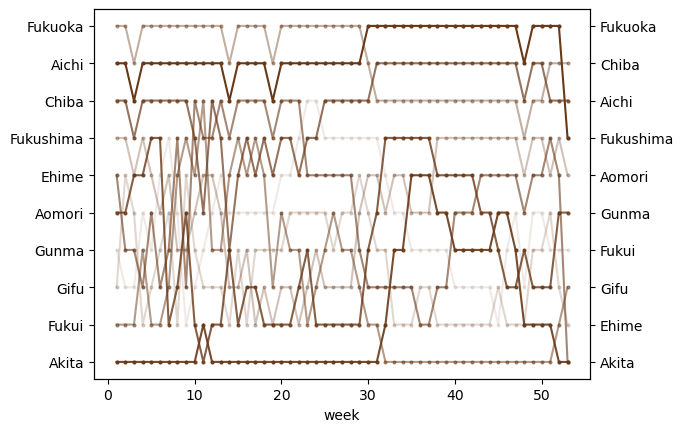

In [325]:
fig = plt.figure()
ax = fig.add_subplot(111)

alpha = 1
for i in df_ranked.index:
    ax.plot(df_ranked.loc[i, :], color = '#683817', alpha = alpha)
    ax.scatter(np.arange(1, len(df_ranked.loc[i, :])+1, 1), df_ranked.loc[i, :], s = 4, color = '#683817', alpha = alpha)
    alpha -= .1

index_labels = df_ranked.index.tolist()
index_labels.reverse()
ax.set(yticks = np.arange(1, 11, 1), yticklabels = df_ranked[1].sort_values().index, xlabel = 'week')

ax2 = ax.twinx()
ax2.set(yticks = np.arange(1, 11, 1), yticklabels = df_ranked[53].sort_values().index)
for i in df_ranked.index:
    ax2.plot(df_ranked.loc[i, :], color = '#683817', alpha = 0)

fig.savefig('./figures/assignment4/bump_plot.png', dpi = 500)

In [320]:
df_ranked[1].sort_values().index

Index(['Akita', 'Fukui', 'Gifu', 'Gunma', 'Aomori', 'Ehime', 'Fukushima',
       'Chiba', 'Aichi', 'Fukuoka'],
      dtype='object', name='Prefecture')